#### 경로 / 분석 구간

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
import figure_npj as npj

DATA_DIR = 'data'
middle_legs = [9, 10, 11, 12, 19, 20]
upper_legs = [13, 14, 21, 22]
groups = {'Middle': middle_legs, 'Upper': upper_legs}
group_of = {leg: group for group, legs in groups.items() for leg in legs}
legs = list(group_of)
threshold, max_lag_seconds = 1 / np.e, 60
low_quantile, high_quantile = 0.2, 0.8
L, N, DV = 'L (g m-3)', 'N (cm-3)', 'Dv (μm)'

In [49]:
iwg = pd.read_csv(f'{DATA_DIR}/iwg1_20170718.txt', skiprows=[1], na_values=[-9999])
fcdp = pd.read_excel(f'{DATA_DIR}/fcdp_20170718.xlsx', usecols='A:D', na_values=[-9999])
print('airplane:', iwg.shape, '/ cloud:', fcdp.shape)
display(fcdp.head())

iwg['Date_Time'] = pd.to_datetime(iwg['Date_Time'], utc=True)
clock = iwg['Date_Time'].dt
iwg['Time'] = clock.hour * 3600 + clock.minute * 60 + clock.second
fcdp['Time'] = fcdp['Time'].astype(int)

data = (iwg.merge(fcdp, on='Time', how='inner')
        .sort_values('Time').reset_index(drop=True))

airplane: (12762, 41) / cloud: (12591, 4)


,Time,N (cm-3),L (g m-3),Dv (μm)
0,30720,0.537330,3.096619e-05,4.792359
1,30721,0.596790,5.969875e-05,5.759460
2,30722,0.247326,4.954283e-05,7.259461
3,30723,0.135298,6.762518e-07,2.121320
4,30724,1.141196,5.258015e-04,9.582694


In [3]:
selected = data[data['Leg_num'].isin(legs)].copy()
blocks = {leg: selected[selected['Leg_num'] == leg].reset_index(drop=True) for leg in legs}
print('선택한 1초 관측 수:', len(selected))
print('Flag_qc 값:', sorted(selected['Flag_qc'].dropna().unique()))

선택한 1초 관측 수: 2694
Flag_qc 값: [np.int64(10776)]


In [4]:
def ground_distance(block):
    speed = block['Grnd_Spd'].to_numpy()
    steps = (speed[:-1] + speed[1:]) / 2 * np.diff(block['Time'])
    return np.r_[0, np.cumsum(steps)]

def lag_curve(y, t, distance):
    elapsed = t - t[0]
    x = y - np.polyval(np.polyfit(elapsed, y, 1), elapsed)
    rows = [(0, 0.0, 1.0)]
    for k in range(1, min(max_lag_seconds, len(x) // 4) + 1):
        rho = np.corrcoef(x[:-k], x[k:])[0, 1]
        km = np.median(distance[k:] - distance[:-k]) / 1000
        rows.append((k, km, rho))
    return pd.DataFrame(rows, columns=['lag_seconds', 'distance_km', 'rho'])

In [5]:
summaries, all_curves = [], {}
for leg, b in blocks.items():
    curve = lag_curve(b[L].to_numpy(), b['Time'].to_numpy(), ground_distance(b))
    all_curves[leg] = curve
    first = curve.loc[(curve['lag_seconds'] > 0) & (curve['rho'] <= threshold)].head(1)
    summaries.append({
        'leg': leg, 'group': group_of[leg],
        'start_utc': b['Date_Time'].iloc[0].strftime('%H:%M:%S'),
        'end_utc': b['Date_Time'].iloc[-1].strftime('%H:%M:%S'),
        'n_seconds': len(b), 'altitude_median_m': b['GPS_MSL_Alt'].median(),
        'cloud_fraction': b['Flag_cloud'].mean(),
        'cross_km': first['distance_km'].iloc[0] if len(first) else np.nan,
        'cross_lag_s': float(first['lag_seconds'].iloc[0]) if len(first) else np.nan,
    })
summary = pd.DataFrame(summaries)
display(summary.round(3))

group_summary = summary.groupby('group', sort=False).agg(
    n_legs=('leg', 'size'), n_seconds=('n_seconds', 'sum'),
    median_km=('cross_km', 'median'), min_km=('cross_km', 'min'), max_km=('cross_km', 'max'),
)
display(group_summary.round(3))
distance_ratio = group_summary.loc['Middle', 'median_km'] / group_summary.loc['Upper', 'median_km']
print(f'중간 높이 / 위쪽의 거리 중앙값 비: {distance_ratio:.2f}')

,leg,group,start_utc,end_utc,n_seconds,altitude_median_m,cloud_fraction,cross_km,cross_lag_s
0,9,Middle,09:45:23,09:50:02,280,755.0,1.000,1.488,16.0
1,10,Middle,09:51:16,09:55:44,269,757.0,1.000,0.660,7.0
2,11,Middle,09:58:51,10:03:07,257,853.0,1.000,0.366,4.0
3,12,Middle,10:04:19,10:08:42,264,851.0,1.000,1.128,11.0
4,19,Middle,11:13:15,11:18:15,301,811.0,1.000,1.105,12.0
5,20,Middle,11:19:30,11:24:21,292,813.0,1.000,1.123,12.0
6,13,Upper,10:11:45,10:16:03,259,975.0,0.981,0.189,2.0
7,14,Upper,10:17:55,10:21:58,244,974.0,1.000,0.191,2.0
8,21,Upper,11:27:11,11:31:24,254,942.0,0.969,0.173,2.0
9,22,Upper,11:32:36,11:37:09,274,945.0,1.000,0.206,2.0


,n_legs,n_seconds,median_km,min_km,max_km
group,,,,,
Middle,6,1663,1.114,0.366,1.488
Upper,4,1031,0.190,0.173,0.206


중간 높이 / 위쪽의 거리 중앙값 비: 5.86


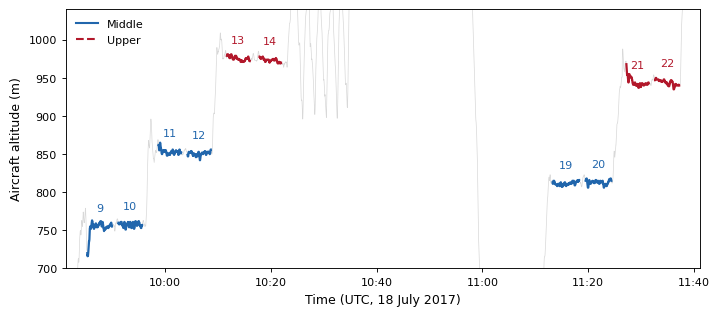

In [6]:
from matplotlib.lines import Line2D
npj.apply_npj()
BLUE, ORANGE = npj.HAD_BLUE, npj.OISST_RED
GREY, INK = npj.TREND_GRAY, npj.OBSERVED_BLACK
COLORS = {'Middle': BLUE, 'Upper': ORANGE}
STYLES = {'Middle': '-', 'Upper': '--'}
WIDTH = npj.PAPER_WIDTH_MM / 25.4

def polish(ax):
    npj.closed_frame(ax)
    ax.grid(False)

def group_legend(ax, loc='upper right'):
    handles = [Line2D([], [], color=COLORS[g], lw=1.5, ls=STYLES[g], label=g) for g in groups]
    ax.legend(handles=handles, frameon=False, loc=loc, fontsize=8)

fig, ax = plt.subplots(figsize=(WIDTH, 3.05), layout='constrained')
ax.plot(data['Date_Time'], data['GPS_MSL_Alt'], color='#D8D8D8', lw=0.5)
for leg, b in blocks.items():
    color = COLORS[group_of[leg]]
    ax.plot(b['Date_Time'], b['GPS_MSL_Alt'], color=color, lw=1.6)
    t, z = b['Date_Time'].iloc[len(b) // 2], b['GPS_MSL_Alt'].median()
    ax.annotate(str(leg), (t, z), xytext=(0, 11), textcoords='offset points',
                ha='center', fontsize=8, color=color)
margin = pd.Timedelta(minutes=4)
ax.set(xlim=(selected['Date_Time'].min() - margin, selected['Date_Time'].max() + margin),
       ylim=(700, 1040), xlabel='Time (UTC, 18 July 2017)', ylabel='Aircraft altitude (m)')
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 20, 40]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
group_legend(ax, 'upper left')
polish(ax)
plt.show()

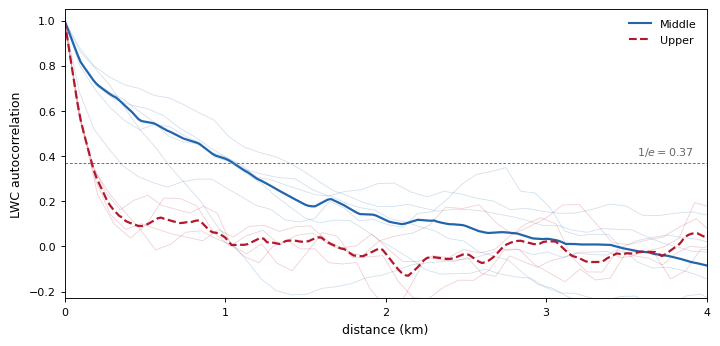

In [7]:
fig, ax = plt.subplots(figsize=(WIDTH, 3.35), layout='constrained')
grid = np.linspace(0, 4, 201)
for group, group_legs in groups.items():
    values = []
    for leg in group_legs:
        curve = all_curves[leg]
        ax.plot(curve['distance_km'], curve['rho'],
                color=COLORS[group], alpha=0.20, lw=0.6)
        values.append(np.interp(grid, curve['distance_km'], curve['rho']))
    ax.plot(grid, np.median(values, axis=0), color=COLORS[group],
            lw=1.6, ls=STYLES[group], label=group)
ax.axhline(threshold, color=GREY, ls=(0, (3, 2)), lw=0.65)
ax.text(3.92, threshold + 0.035, r'$1/e = 0.37$', ha='right', color=GREY, fontsize=8)
ax.set(xlim=(0, 4), ylim=(-0.23, 1.05),
       xlabel='distance (km)', ylabel='LWC autocorrelation')
ax.set_xticks([0, 1, 2, 3, 4])
group_legend(ax)
polish(ax)
plt.show()

In [8]:
micro_rows = []
for leg in upper_legs:
    block = blocks[leg]
    cloud = block[(block['Flag_cloud'] == 1) & (block[[L, N, DV]] > 0).all(axis=1)]
    low_edge, high_edge = cloud[L].quantile([low_quantile, high_quantile])
    low, high = cloud[cloud[L] <= low_edge], cloud[cloud[L] >= high_edge]
    low_median, high_median = low[[L, N, DV]].median(), high[[L, N, DV]].median()
    row = {'leg': leg, 'group': group_of[leg], 'n_cloud_positive': len(cloud),
           'n_low': len(low), 'n_high': len(high),
           'low_L_cutoff': low_edge, 'high_L_cutoff': high_edge}
    for col, short in zip([L, N, DV], ['L', 'N', 'Dv']):
        row.update({f'{short}_low_median': low_median[col],
                    f'{short}_high_median': high_median[col],
                    f'{short}_low_over_high': low_median[col] / high_median[col]})
    row['Dv_expected_uniform_shrink'] = row['L_low_over_high'] ** (1 / 3)
    micro_rows.append(row)
upper_micro = pd.DataFrame(micro_rows)
ratio_cols = ['L_low_over_high', 'N_low_over_high', 'Dv_low_over_high']
display(upper_micro[['leg', 'n_low', 'n_high', *ratio_cols]].round(3))

positive = selected[(selected[L] > 0) & (selected[N] > 0) & (selected[DV] > 0)]
identity_ratio = positive[L] / (np.pi / 6 * 1e-6 * positive[N] * positive[DV]**3)
print('LWC/N/Dv 관계의 최대 상대 오차:', np.abs(identity_ratio - 1).max())
display(upper_micro[ratio_cols].median().round(3))

,leg,n_low,n_high,L_low_over_high,N_low_over_high,Dv_low_over_high
0,13,51,51,0.270,0.328,0.901
1,14,49,49,0.340,0.313,0.986
2,21,49,49,0.174,0.176,0.940
3,22,55,55,0.286,0.326,0.954


LWC/N/Dv 관계의 최대 상대 오차: 1.4654943925052066e-14


L_low_over_high     0.278
N_low_over_high     0.320
Dv_low_over_high    0.947
dtype: float64

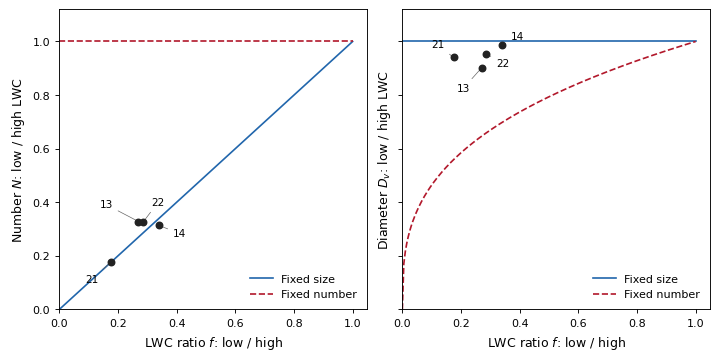

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(WIDTH, 3.5), layout='constrained', sharey=True)
fgrid = np.linspace(0, 1, 201)
axes[0].plot(fgrid, fgrid, color=BLUE, lw=1.2, label='Fixed size')
axes[0].plot(fgrid, np.ones_like(fgrid), color=ORANGE, lw=1.2, ls='--', label='Fixed number')
axes[1].plot(fgrid, np.ones_like(fgrid), color=BLUE, lw=1.2, label='Fixed size')
axes[1].plot(fgrid, fgrid**(1/3), color=ORANGE, lw=1.2, ls='--', label='Fixed number')
offsets = ({13: (-28, 10), 14: (10, -8), 21: (-18, -14), 22: (6, 12)},
           {13: (-18, -17), 14: (6, 4), 21: (-16, 7), 22: (7, -9)})
for ax, col, offset in zip(axes, ['N_low_over_high', 'Dv_low_over_high'], offsets):
    ax.scatter(upper_micro['L_low_over_high'], upper_micro[col], color=INK, s=22, zorder=4)
    for _, row in upper_micro.iterrows():
        ax.annotate(str(int(row['leg'])), (row['L_low_over_high'], row[col]),
                    xytext=offset[row['leg']], textcoords='offset points', fontsize=7.5,
                    arrowprops={'arrowstyle': '-', 'lw': 0.5, 'color': GREY})
    ax.set(xlim=(0, 1.05), ylim=(0, 1.12), xlabel=r'LWC ratio $f$: low / high')
    ax.legend(frameon=False, loc='lower right', fontsize=8)
    polish(ax)
axes[0].set_ylabel(r'Number $N$: low / high LWC')
axes[1].set_ylabel(r'Diameter $D_v$: low / high LWC')
plt.show()